# Time Series KPI Visualization in Python
## A simple, practical 120-minute class

This notebook teaches the **simplest useful ways to visualize time series KPIs in Python**.

We will use only:

- `pandas`
- `numpy`
- `matplotlib`

No external data files are required. The notebook generates a small synthetic dataset so it runs anywhere.

### Learning goals

By the end of the class, you should be able to:

1. Prepare a KPI dataset with a proper time index.
2. Draw a basic KPI trend line.
3. Improve readability with labels, grids, and sensible formatting.
4. Compare actual values with a target.
5. Add rolling averages to reduce noise.
6. Visualize percentage change.
7. Aggregate daily data into weekly or monthly views.
8. Compare multiple KPIs without making the chart unreadable.
9. Build small multiples.
10. Highlight unusually high or low periods.

### Suggested 120-minute teaching plan

| Section | Topic | Time |
|---|---|---:|
| 1 | Setup and data | 10 min |
| 2 | The simplest time-series chart | 15 min |
| 3 | Make the chart readable | 10 min |
| 4 | Actual vs target | 15 min |
| 5 | Rolling averages | 15 min |
| 6 | Change over time | 15 min |
| 7 | Resampling and aggregation | 15 min |
| 8 | Multiple KPIs and small multiples | 15 min |
| 9 | Highlighting unusual periods | 5 min |
| 10 | Recap exercise | 5 min |

**Total: 120 minutes**

> **Expanded manual-data edition**
>
> All original material below is preserved. The added cells give students a second route through each topic:
> they can replace the example values with their **own manually entered dates and KPI values**.
>
> For a 120-minute class, treat the manual-data cells as **swap-in practice**, not as extra lecture time:
> demonstrate the original example, then let students repeat the same technique with their own small dataset.

## 1. Setup and sample KPI data — 10 minutes

A time-series KPI dataset usually has:

- one **time column**,
- one or more **metric columns**,
- optionally a **target**, category, region, product, or segment.

For teaching purposes, we create daily data for:

- `revenue`
- `orders`
- `conversion_rate`
- `revenue_target`

The data contains trend, weekly seasonality, and random noise.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make random values reproducible
rng = np.random.default_rng(42)

# 180 daily observations
dates = pd.date_range("2026-01-01", periods=180, freq="D")
t = np.arange(len(dates))

# Create synthetic KPIs
revenue = (
    120_000
    + 350 * t
    + 12_000 * np.sin(2 * np.pi * t / 7)
    + rng.normal(0, 7_000, len(t))
)

orders = (
    1_900
    + 4 * t
    + 180 * np.sin(2 * np.pi * t / 7)
    + rng.normal(0, 90, len(t))
)

conversion_rate = (
    3.2
    + 0.002 * t
    + 0.18 * np.sin(2 * np.pi * t / 14)
    + rng.normal(0, 0.08, len(t))
)

revenue_target = 125_000 + 320 * t

df = pd.DataFrame({
    "date": dates,
    "revenue": revenue,
    "orders": orders,
    "conversion_rate": conversion_rate,
    "revenue_target": revenue_target,
})

df.head()

,date,revenue,orders,conversion_rate,revenue_target
0,2026-01-01,122133.019558,2017.540157,3.187798,125000
1,2026-01-02,122452.089046,2064.474092,3.310771,125320
2,2026-01-03,137652.293317,2046.503573,3.424716,125640
3,2026-01-04,132840.557884,2089.665057,3.296804,125960
4,2026-01-05,102536.148810,1876.489006,3.373486,126280


### Teaching point: dates should be real datetimes

Always check the time column. Pandas gives much better plotting and aggregation behavior when dates are stored as `datetime64`.

In [2]:
df.dtypes

date               datetime64[ns]
revenue                   float64
orders                    float64
conversion_rate           float64
revenue_target              int64
dtype: object

In [3]:
# A common preparation step:
df["date"] = pd.to_datetime(df["date"])

# Put date on the index.
# This makes time-series operations especially convenient.
ts = df.set_index("date")

ts.head()

,revenue,orders,conversion_rate,revenue_target
date,,,,
2026-01-01,122133.019558,2017.540157,3.187798,125000
2026-01-02,122452.089046,2064.474092,3.310771,125320
2026-01-03,137652.293317,2046.503573,3.424716,125640
2026-01-04,132840.557884,2089.665057,3.296804,125960
2026-01-05,102536.148810,1876.489006,3.373486,126280


### Quick inspection

Before plotting, check:

- missing values,
- date range,
- number of observations,
- basic summary statistics.

In [4]:
print("Date range:", ts.index.min().date(), "to", ts.index.max().date())
print("Rows:", len(ts))
print("\nMissing values:")
print(ts.isna().sum())

ts.describe().round(2)

Date range: 2026-01-01 to 2026-06-29
Rows: 180

Missing values:
revenue            0
orders             0
conversion_rate    0
revenue_target     0
dtype: int64


,revenue,orders,conversion_rate,revenue_target
count,180.00,180.00,180.00,180.00
mean,151044.76,2263.20,3.38,153640.00
std,20694.63,264.38,0.18,16673.81
min,100935.61,1738.03,2.94,125000.00
25%,134401.43,2074.85,3.25,139320.00
50%,150797.57,2251.34,3.38,153640.00
75%,165629.56,2480.83,3.50,167960.00
max,202035.62,2849.57,3.79,182280.00


### Manual data lab A — enter your own KPI data

The simplest classroom-friendly way to enter a small dataset is a **list of rows**.

Each row is one date and its KPI values. Students can edit the dates and numbers directly.

In [ ]:
# MANUAL DATA ENTRY — edit these rows directly.
# Keep the column names the same in every row.

my_manual_data = [
    {"date": "2026-01-01", "revenue": 105000, "orders": 1680, "conversion_rate": 3.10},
    {"date": "2026-01-02", "revenue": 112000, "orders": 1750, "conversion_rate": 3.20},
    {"date": "2026-01-03", "revenue": 109500, "orders": 1715, "conversion_rate": 3.15},
    {"date": "2026-01-04", "revenue": 118000, "orders": 1825, "conversion_rate": 3.30},
    {"date": "2026-01-05", "revenue": 121500, "orders": 1890, "conversion_rate": 3.40},
    {"date": "2026-01-06", "revenue": 119000, "orders": 1850, "conversion_rate": 3.35},
    {"date": "2026-01-07", "revenue": 126000, "orders": 1940, "conversion_rate": 3.50},
]

my_manual_df = pd.DataFrame(my_manual_data)
my_manual_df["date"] = pd.to_datetime(my_manual_df["date"])

my_manual_df

#### Turn manually entered rows into a time series

The same preparation rule applies:

1. convert the date column with `pd.to_datetime()`,
2. put the date on the index with `set_index()`,
3. sort the dates.

Sorting is a useful safety step when students type dates by hand.

In [ ]:
my_manual_ts = (
    my_manual_df
    .set_index("date")
    .sort_index()
)

my_manual_ts

#### Validate manually typed data

Manual entry creates common mistakes such as:

- one missing value,
- a date typed in the wrong order,
- a number entered as text,
- duplicate dates.

Run a few checks before plotting.

In [ ]:
print("Rows:", len(my_manual_ts))
print("Date range:", my_manual_ts.index.min().date(), "to", my_manual_ts.index.max().date())

print("\nMissing values:")
print(my_manual_ts.isna().sum())

print("\nDuplicate dates:", my_manual_ts.index.duplicated().sum())

print("\nColumn types:")
print(my_manual_ts.dtypes)

### Manual data lab B — an even smaller one-KPI template

When the lesson focuses on visualization rather than data preparation, students can start with just two columns.

In [ ]:
# STUDENT TEMPLATE
# Replace the dates and KPI values below.

student_data = [
    {"date": "2026-02-01", "kpi": 100},
    {"date": "2026-02-02", "kpi": 104},
    {"date": "2026-02-03", "kpi": 102},
    {"date": "2026-02-04", "kpi": 109},
    {"date": "2026-02-05", "kpi": 113},
    {"date": "2026-02-06", "kpi": 111},
    {"date": "2026-02-07", "kpi": 117},
]

student_df = pd.DataFrame(student_data)
student_df["date"] = pd.to_datetime(student_df["date"])
student_ts = student_df.set_index("date").sort_index()

student_ts

### Optional: collect values with `input()`

Editing a Python list is usually fastest in class. If you want students to type one observation at a time,
the function below uses notebook input boxes.

**It is defined but not called automatically**, so the notebook remains runnable from top to bottom.
To use it, run the cell and then call:

```python
typed_df = collect_kpi_rows()
```

In [ ]:
def collect_kpi_rows():
    """Collect a small time series interactively from notebook input boxes."""
    n = int(input("How many observations do you want to enter? "))

    rows = []
    for i in range(n):
        print(f"Observation {i + 1} of {n}")
        date = input("  Date (YYYY-MM-DD): ")
        value = float(input("  KPI value: "))
        rows.append({"date": date, "kpi": value})

    result = pd.DataFrame(rows)
    result["date"] = pd.to_datetime(result["date"])
    result = result.set_index("date").sort_index()
    return result

print("Function ready. Call collect_kpi_rows() when you want interactive entry.")

## 2. The simplest time-series chart — 15 minutes

The default choice for a KPI over time is usually a **line chart**.

Why?

- time has an inherent order,
- the line makes direction and movement easy to see,
- the chart can show trend, noise, seasonality, spikes, and dips.

The simplest Pandas version is one line of plotting code.

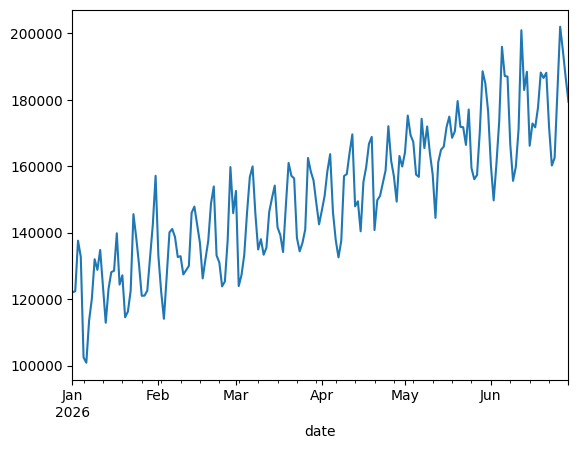

In [5]:
ts["revenue"].plot()
plt.show()

That works, but it is not presentation-ready.

A slightly better version adds:

- figure size,
- title,
- axis labels,
- light grid,
- tight layout.

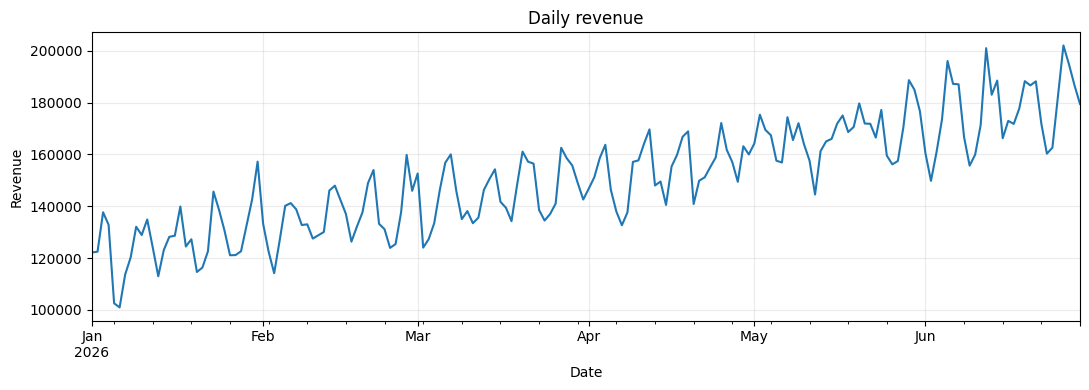

In [6]:
ax = ts["revenue"].plot(figsize=(11, 4))

ax.set_title("Daily revenue")
ax.set_xlabel("Date")
ax.set_ylabel("Revenue")
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

### Exercise 1 — 5 minutes

Create a line chart for `orders`.

Try to include:

- a title,
- an x-axis label,
- a y-axis label,
- a grid.

A solution is hidden in the next cell. Try first.

In [7]:
# Exercise 1: your code here

# Example starting point:
# ax = ts["orders"].plot(figsize=(11, 4))

### Exercise 1 solution

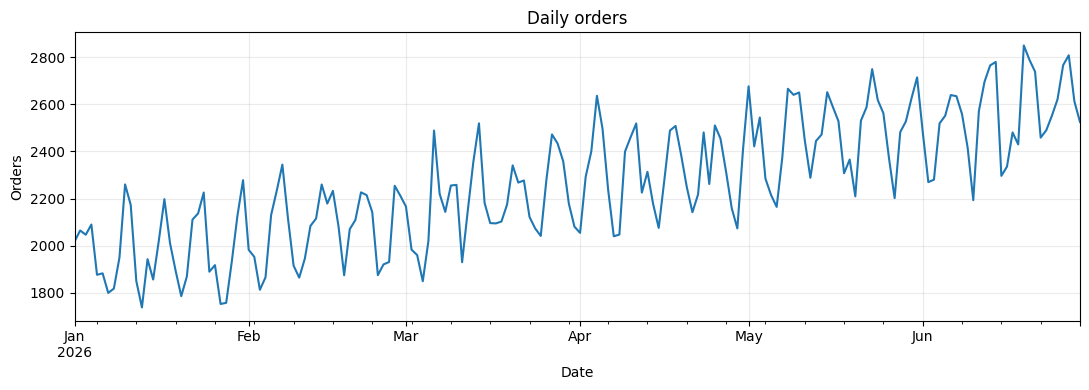

In [8]:
ax = ts["orders"].plot(figsize=(11, 4))

ax.set_title("Daily orders")
ax.set_xlabel("Date")
ax.set_ylabel("Orders")
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

### Manual practice — plot a KPI that students typed themselves

This uses `student_ts` from the manual-entry section.

Students only need to change the values in the earlier template and rerun this cell.

In [ ]:
ax = student_ts["kpi"].plot(figsize=(11, 4), marker="o")

ax.set_title("My manually entered KPI")
ax.set_xlabel("Date")
ax.set_ylabel("KPI")
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

#### Manual practice task

Change at least three KPI values in `student_data`, rerun the data cell, then rerun the plot.

Discuss:

- Which day is highest?
- Is the trend rising, falling, or mixed?
- Does connecting the points with a line make sense for this KPI?

## 3. Make KPI charts easier to read — 10 minutes

Good KPI visualization is less about decoration and more about removing friction.

Useful improvements:

1. Use a clear title.
2. Include the unit.
3. Avoid unnecessary legends when only one series is shown.
4. Format large numbers.
5. Keep grid lines subtle.
6. Use enough horizontal space for dates.

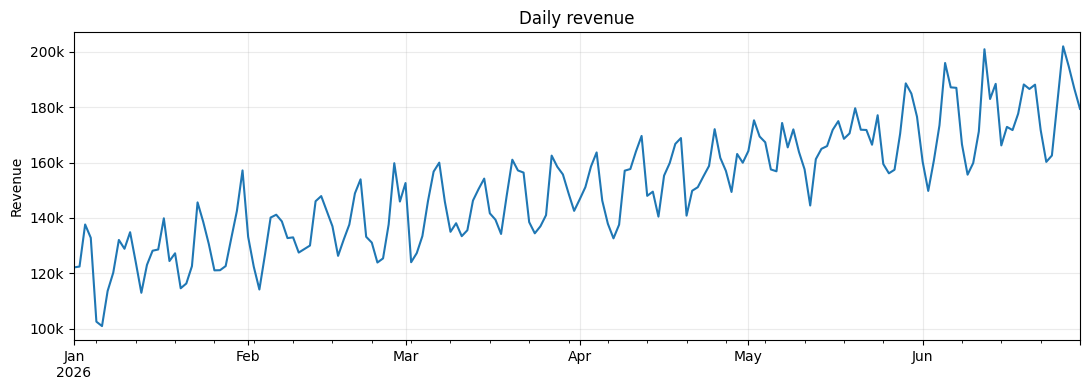

In [9]:
from matplotlib.ticker import FuncFormatter

def thousands_formatter(x, position):
    return f"{x/1000:.0f}k"

ax = ts["revenue"].plot(figsize=(11, 4), legend=False)

ax.set_title("Daily revenue")
ax.set_xlabel("")
ax.set_ylabel("Revenue")
ax.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

### Teaching discussion

Ask the class:

- What question does this chart answer?
- What can you see immediately?
- What can you *not* see immediately?
- Would daily granularity always be useful?
- When would weekly or monthly aggregation be better?

This prepares the class for the next sections.

### Manual practice — format large KPI values

Students can enter a KPI with larger values, such as revenue, costs, impressions, or units produced.

In [ ]:
manual_large_kpi = [
    {"date": "2026-03-01", "sales": 95000},
    {"date": "2026-03-02", "sales": 103000},
    {"date": "2026-03-03", "sales": 101500},
    {"date": "2026-03-04", "sales": 110000},
    {"date": "2026-03-05", "sales": 116500},
    {"date": "2026-03-06", "sales": 114000},
    {"date": "2026-03-07", "sales": 121000},
]

manual_large_df = pd.DataFrame(manual_large_kpi)
manual_large_df["date"] = pd.to_datetime(manual_large_df["date"])
manual_large_ts = manual_large_df.set_index("date").sort_index()

ax = manual_large_ts["sales"].plot(figsize=(11, 4), marker="o", legend=False)

ax.set_title("Manually entered sales")
ax.set_xlabel("")
ax.set_ylabel("Sales")
ax.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

**Student variation:** replace `sales` with another large-number KPI and update the chart title and y-axis label.

## 4. Actual vs target — 15 minutes

A KPI often becomes much more meaningful when compared with a target.

The simplest approach is to plot both series on the same axis **when they use the same unit**.

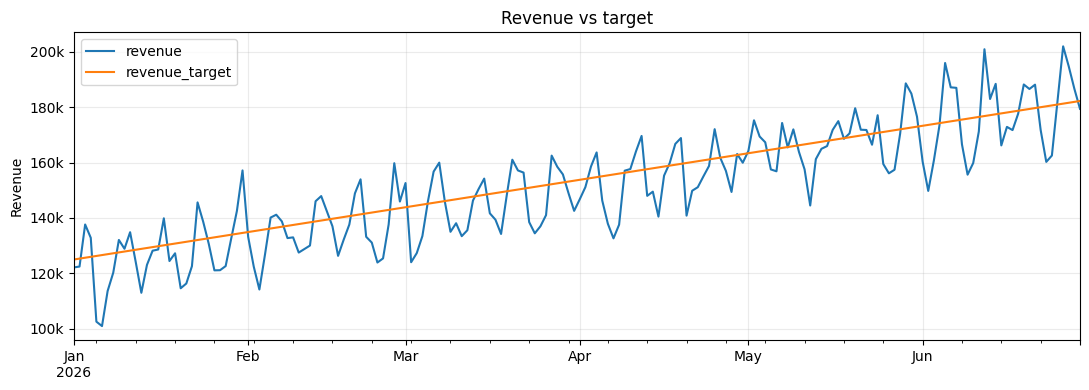

In [10]:
ax = ts[["revenue", "revenue_target"]].plot(figsize=(11, 4))

ax.set_title("Revenue vs target")
ax.set_xlabel("")
ax.set_ylabel("Revenue")
ax.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

### Add the variance

For management reporting, the chart often becomes more useful when paired with a calculated gap.

In [11]:
ts["revenue_vs_target"] = ts["revenue"] - ts["revenue_target"]

ts[["revenue", "revenue_target", "revenue_vs_target"]].head()

,revenue,revenue_target,revenue_vs_target
date,,,
2026-01-01,122133.019558,125000,-2866.980442
2026-01-02,122452.089046,125320,-2867.910954
2026-01-03,137652.293317,125640,12012.293317
2026-01-04,132840.557884,125960,6880.557884
2026-01-05,102536.148810,126280,-23743.851190


The variance itself is easier to interpret in a separate chart because it has a different visual question:

> Are we above or below target, and by how much?

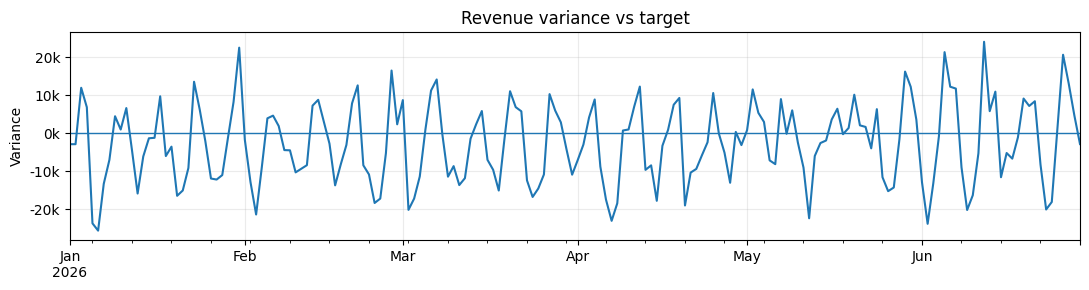

In [12]:
ax = ts["revenue_vs_target"].plot(figsize=(11, 3))

ax.axhline(0, linewidth=1)
ax.set_title("Revenue variance vs target")
ax.set_xlabel("")
ax.set_ylabel("Variance")
ax.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

### Exercise 2 — 5 minutes

Create a boolean KPI called `above_target` that is `True` when revenue is above target.

Then calculate the percentage of days above target.

In [13]:
# Exercise 2: your code here

### Exercise 2 solution

In [14]:
ts["above_target"] = ts["revenue"] > ts["revenue_target"]

share_above_target = ts["above_target"].mean()

print(f"Share of days above target: {share_above_target:.1%}")

Share of days above target: 40.0%


### Manual practice — actual vs target with student-entered values

Many business KPIs are easier to interpret when the student enters both an **actual** and a **target**.

In [ ]:
student_target_data = [
    {"date": "2026-04-01", "actual": 98000,  "target": 100000},
    {"date": "2026-04-02", "actual": 104000, "target": 101000},
    {"date": "2026-04-03", "actual": 103000, "target": 102000},
    {"date": "2026-04-04", "actual": 107500, "target": 103000},
    {"date": "2026-04-05", "actual": 102500, "target": 104000},
    {"date": "2026-04-06", "actual": 110000, "target": 105000},
    {"date": "2026-04-07", "actual": 112000, "target": 106000},
]

student_target_df = pd.DataFrame(student_target_data)
student_target_df["date"] = pd.to_datetime(student_target_df["date"])
student_target_ts = student_target_df.set_index("date").sort_index()

ax = student_target_ts[["actual", "target"]].plot(figsize=(11, 4), marker="o")

ax.set_title("My KPI: actual vs target")
ax.set_xlabel("")
ax.set_ylabel("Value")
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

#### Calculate the manually entered target gap

In [ ]:
student_target_ts["variance"] = (
    student_target_ts["actual"] - student_target_ts["target"]
)

student_target_ts["above_target"] = (
    student_target_ts["actual"] > student_target_ts["target"]
)

print(student_target_ts)

print(
    "\nShare of manually entered periods above target:",
    f"{student_target_ts['above_target'].mean():.1%}"
)

In [ ]:
ax = student_target_ts["variance"].plot(figsize=(11, 3), marker="o")

ax.axhline(0, linewidth=1)
ax.set_title("My KPI variance vs target")
ax.set_xlabel("")
ax.set_ylabel("Actual - target")
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

**Student ideas:** enter sales vs budget, orders vs plan, response time vs SLA threshold,
output vs production target, or website visits vs campaign goal.

## 5. Rolling averages: make noisy KPIs easier to read — 15 minutes

Daily KPI data can be noisy.

A rolling average answers:

> What is the recent underlying level?

A **7-day rolling average** is especially intuitive for daily data because it smooths out day-of-week effects.

In [15]:
ts["revenue_7d_avg"] = ts["revenue"].rolling(7).mean()

ts[["revenue", "revenue_7d_avg"]].head(10)

,revenue,revenue_7d_avg
date,,
2026-01-01,122133.019558,NaN
2026-01-02,122452.089046,NaN
2026-01-03,137652.293317,NaN
2026-01-04,132840.557884,NaN
2026-01-05,102536.148810,NaN
2026-01-06,100935.608506,NaN
2026-01-07,113612.905033,118880.374593
2026-01-08,120236.301854,118609.414921
2026-01-09,132064.369687,119982.597870


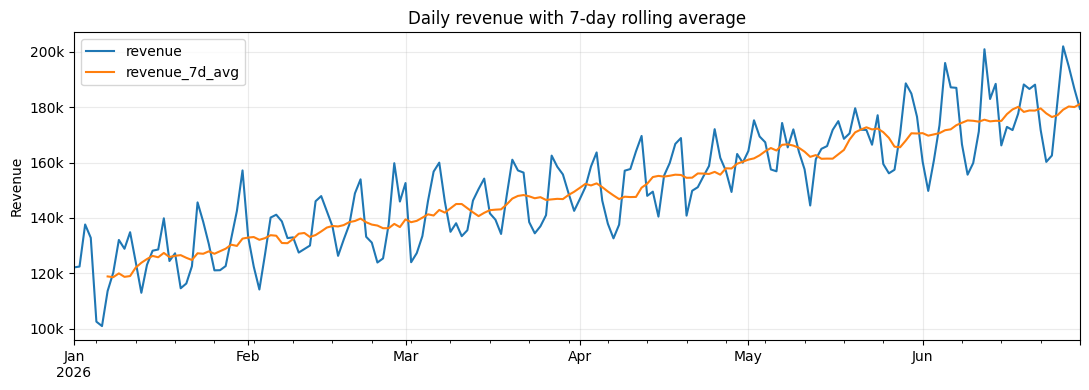

In [16]:
ax = ts[["revenue", "revenue_7d_avg"]].plot(figsize=(11, 4))

ax.set_title("Daily revenue with 7-day rolling average")
ax.set_xlabel("")
ax.set_ylabel("Revenue")
ax.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

### Compare 7-day and 30-day smoothing

A shorter window reacts faster.  
A longer window is smoother but reacts more slowly.

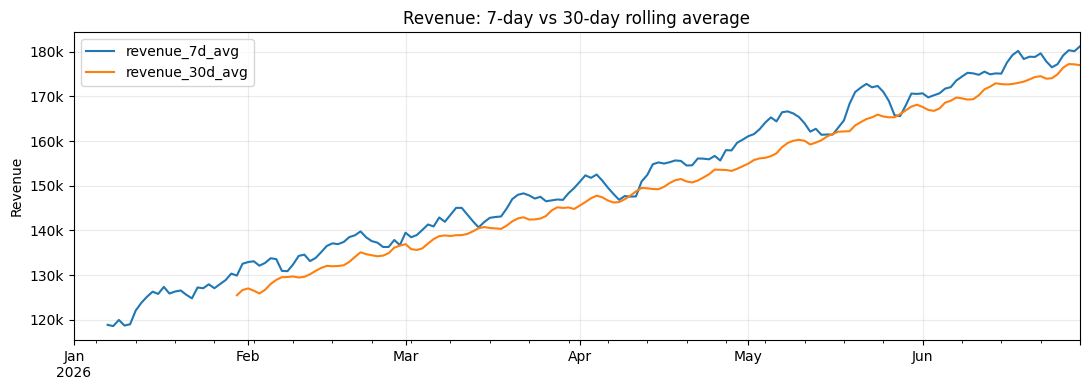

In [17]:
ts["revenue_30d_avg"] = ts["revenue"].rolling(30).mean()

ax = ts[["revenue_7d_avg", "revenue_30d_avg"]].plot(figsize=(11, 4))

ax.set_title("Revenue: 7-day vs 30-day rolling average")
ax.set_xlabel("")
ax.set_ylabel("Revenue")
ax.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

### Teaching point: do not hide raw data too early

A rolling average is a **summary**, not the original KPI.

For operational monitoring, showing both raw and smoothed data can be valuable.

### Manual practice — rolling average on student-entered data

A rolling average becomes visible with a slightly longer series. The cell below uses 14 manually typed observations.

In [ ]:
student_rolling_data = [
    {"date": "2026-05-01", "tickets": 52},
    {"date": "2026-05-02", "tickets": 58},
    {"date": "2026-05-03", "tickets": 49},
    {"date": "2026-05-04", "tickets": 65},
    {"date": "2026-05-05", "tickets": 61},
    {"date": "2026-05-06", "tickets": 70},
    {"date": "2026-05-07", "tickets": 68},
    {"date": "2026-05-08", "tickets": 74},
    {"date": "2026-05-09", "tickets": 69},
    {"date": "2026-05-10", "tickets": 77},
    {"date": "2026-05-11", "tickets": 80},
    {"date": "2026-05-12", "tickets": 76},
    {"date": "2026-05-13", "tickets": 84},
    {"date": "2026-05-14", "tickets": 82},
]

student_rolling_df = pd.DataFrame(student_rolling_data)
student_rolling_df["date"] = pd.to_datetime(student_rolling_df["date"])
student_rolling_ts = student_rolling_df.set_index("date").sort_index()

student_rolling_ts["3_day_average"] = (
    student_rolling_ts["tickets"].rolling(3).mean()
)

ax = student_rolling_ts[["tickets", "3_day_average"]].plot(
    figsize=(11, 4),
    marker="o"
)

ax.set_title("My manually entered KPI with a 3-day rolling average")
ax.set_xlabel("")
ax.set_ylabel("Tickets")
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

#### Student experiment: change the window

Try `rolling(5)` and `rolling(7)`.

The larger the window, the smoother and slower-moving the rolling average becomes.

In [ ]:
student_rolling_ts["5_day_average"] = (
    student_rolling_ts["tickets"].rolling(5).mean()
)

student_rolling_ts["7_day_average"] = (
    student_rolling_ts["tickets"].rolling(7).mean()
)

ax = student_rolling_ts[
    ["tickets", "3_day_average", "5_day_average", "7_day_average"]
].plot(figsize=(11, 4))

ax.set_title("Compare rolling-average windows")
ax.set_xlabel("")
ax.set_ylabel("Tickets")
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

## 6. Visualize change, not only level — 15 minutes

Sometimes the level is less important than the rate of change.

Pandas provides a very simple method:

```python
Series.pct_change()
```

For daily data, the default is day-over-day change.

In [18]:
ts["revenue_daily_change_pct"] = ts["revenue"].pct_change() * 100

ts[["revenue", "revenue_daily_change_pct"]].head()

,revenue,revenue_daily_change_pct
date,,
2026-01-01,122133.019558,NaN
2026-01-02,122452.089046,0.261248
2026-01-03,137652.293317,12.413185
2026-01-04,132840.557884,-3.495572
2026-01-05,102536.148810,-22.812618


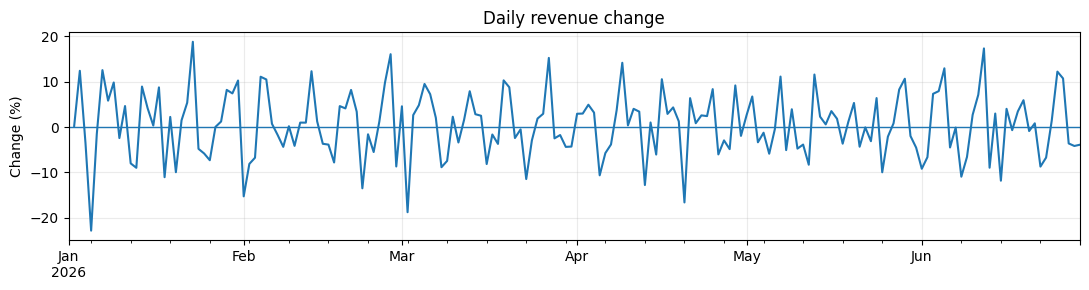

In [19]:
ax = ts["revenue_daily_change_pct"].plot(figsize=(11, 3))

ax.axhline(0, linewidth=1)
ax.set_title("Daily revenue change")
ax.set_xlabel("")
ax.set_ylabel("Change (%)")
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

### Weekly change

Daily percentage change may be too noisy.

For daily data, comparing with 7 days earlier can be more meaningful:

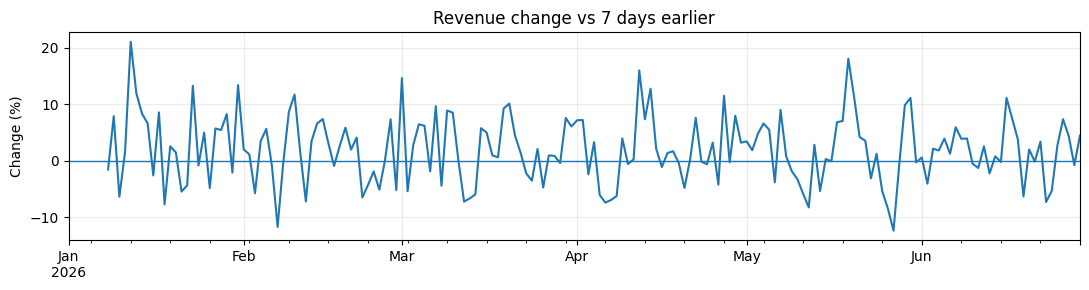

In [20]:
ts["revenue_7d_change_pct"] = ts["revenue"].pct_change(7) * 100

ax = ts["revenue_7d_change_pct"].plot(figsize=(11, 3))

ax.axhline(0, linewidth=1)
ax.set_title("Revenue change vs 7 days earlier")
ax.set_xlabel("")
ax.set_ylabel("Change (%)")
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

### Exercise 3 — 5 minutes

Create a 7-day percentage-change chart for `orders`.

Questions to discuss:

- Is it more stable than daily percentage change?
- Does it tell a different story than the absolute orders chart?

In [21]:
# Exercise 3: your code here

### Exercise 3 solution

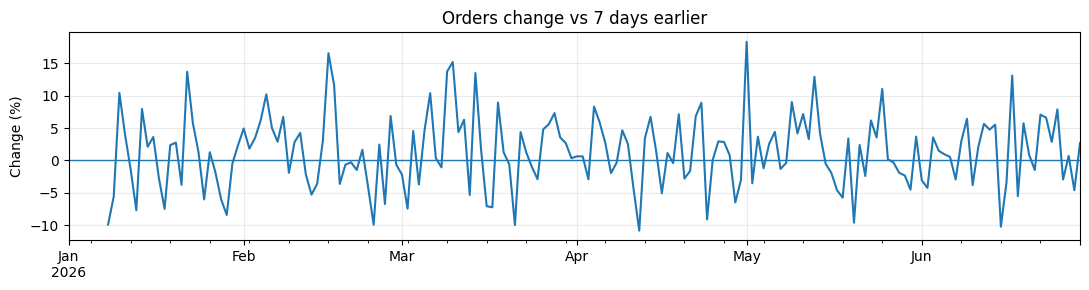

In [22]:
ts["orders_7d_change_pct"] = ts["orders"].pct_change(7) * 100

ax = ts["orders_7d_change_pct"].plot(figsize=(11, 3))

ax.axhline(0, linewidth=1)
ax.set_title("Orders change vs 7 days earlier")
ax.set_xlabel("")
ax.set_ylabel("Change (%)")
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

### Manual practice — percentage change using student-entered values

Weekly values make the percentage-change idea easy to see.

In [ ]:
student_change_data = [
    {"date": "2026-06-07", "signups": 800},
    {"date": "2026-06-14", "signups": 840},
    {"date": "2026-06-21", "signups": 825},
    {"date": "2026-06-28", "signups": 910},
    {"date": "2026-07-05", "signups": 955},
    {"date": "2026-07-12", "signups": 940},
    {"date": "2026-07-19", "signups": 990},
]

student_change_df = pd.DataFrame(student_change_data)
student_change_df["date"] = pd.to_datetime(student_change_df["date"])
student_change_ts = student_change_df.set_index("date").sort_index()

student_change_ts["change_pct"] = (
    student_change_ts["signups"].pct_change() * 100
)

student_change_ts

In [ ]:
ax = student_change_ts["change_pct"].plot(figsize=(11, 3), marker="o")

ax.axhline(0, linewidth=1)
ax.set_title("Change in my manually entered KPI")
ax.set_xlabel("")
ax.set_ylabel("Change (%)")
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

#### Read one percentage change manually

The formula from one period to the next is:

\[
\text{percentage change}
=
\frac{\text{new} - \text{old}}{\text{old}} \times 100
\]

Students can check one pair of values with Python.

In [ ]:
old_value = student_change_ts["signups"].iloc[0]
new_value = student_change_ts["signups"].iloc[1]

manual_change_check = (new_value - old_value) / old_value * 100

print(f"First change: {manual_change_check:.2f}%")
print(
    "Pandas result:",
    f"{student_change_ts['change_pct'].iloc[1]:.2f}%"
)

## 7. Resampling: daily → weekly → monthly — 15 minutes

Granularity should match the business question.

Examples:

- **daily**: operational monitoring,
- **weekly**: team reviews,
- **monthly**: management reporting.

Pandas makes resampling simple.

In [23]:
weekly_revenue = ts["revenue"].resample("W").sum()

weekly_revenue.head()

date
2026-01-04    515077.959805
2026-01-11    833125.552036
2026-01-18    881224.042318
2026-01-25    895666.915618
2026-02-01    930470.841290
Freq: W-SUN, Name: revenue, dtype: float64

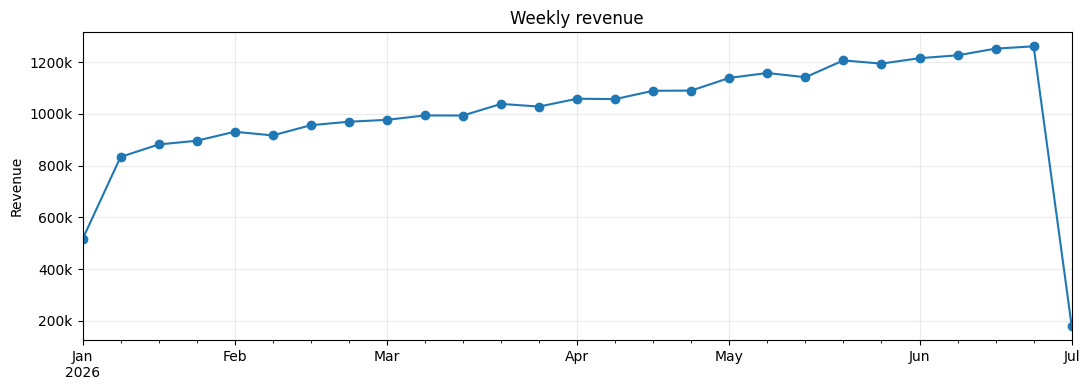

In [24]:
ax = weekly_revenue.plot(figsize=(11, 4), marker="o")

ax.set_title("Weekly revenue")
ax.set_xlabel("")
ax.set_ylabel("Revenue")
ax.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

### Important: choose the aggregation that fits the KPI

For a flow KPI such as revenue or orders:

- weekly **sum** is often appropriate.

For a rate KPI such as conversion rate:

- weekly **mean** is usually more appropriate.

In [25]:
weekly = pd.DataFrame({
    "revenue": ts["revenue"].resample("W").sum(),
    "orders": ts["orders"].resample("W").sum(),
    "conversion_rate": ts["conversion_rate"].resample("W").mean(),
})

weekly.head()

,revenue,orders,conversion_rate
date,,,
2026-01-04,515077.959805,8218.182879,3.305022
2026-01-11,833125.552036,13759.674106,3.223700
2026-01-18,881224.042318,13615.111806,3.270293
2026-01-25,895666.915618,13911.475892,3.220386
2026-02-01,930470.841290,13747.982506,3.219171


### Monthly revenue

With only 180 days, the monthly view is intentionally compact.

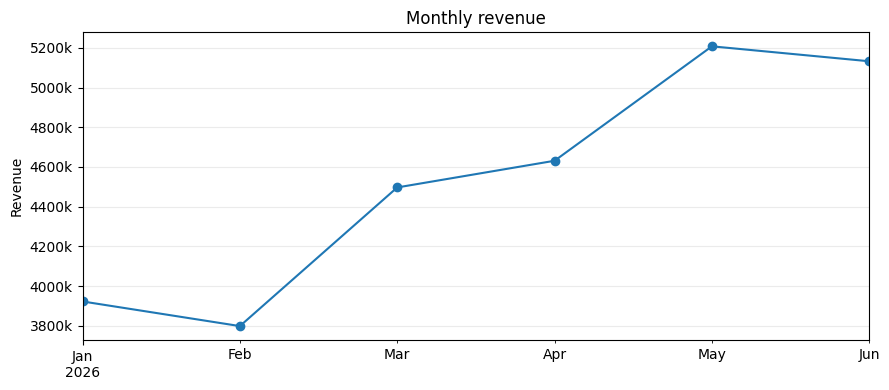

In [26]:
monthly_revenue = ts["revenue"].resample("MS").sum()

ax = monthly_revenue.plot(figsize=(9, 4), marker="o")

ax.set_title("Monthly revenue")
ax.set_xlabel("")
ax.set_ylabel("Revenue")
ax.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

### Manual practice — aggregate student-entered daily data

Students manually enter daily observations, then convert them to weekly values.

Notice that different KPI types need different aggregation rules:

- revenue/orders: often `sum()`
- conversion rate: often `mean()`

In [ ]:
student_daily_data = [
    {"date": "2026-08-01", "revenue": 14000, "orders": 210, "conversion_rate": 3.2},
    {"date": "2026-08-02", "revenue": 15200, "orders": 225, "conversion_rate": 3.3},
    {"date": "2026-08-03", "revenue": 14800, "orders": 218, "conversion_rate": 3.1},
    {"date": "2026-08-04", "revenue": 16100, "orders": 236, "conversion_rate": 3.4},
    {"date": "2026-08-05", "revenue": 17200, "orders": 249, "conversion_rate": 3.5},
    {"date": "2026-08-06", "revenue": 16900, "orders": 245, "conversion_rate": 3.4},
    {"date": "2026-08-07", "revenue": 15800, "orders": 231, "conversion_rate": 3.3},
    {"date": "2026-08-08", "revenue": 16500, "orders": 241, "conversion_rate": 3.5},
    {"date": "2026-08-09", "revenue": 17100, "orders": 250, "conversion_rate": 3.6},
    {"date": "2026-08-10", "revenue": 17600, "orders": 258, "conversion_rate": 3.5},
    {"date": "2026-08-11", "revenue": 18100, "orders": 264, "conversion_rate": 3.7},
    {"date": "2026-08-12", "revenue": 18800, "orders": 275, "conversion_rate": 3.8},
    {"date": "2026-08-13", "revenue": 18500, "orders": 270, "conversion_rate": 3.7},
    {"date": "2026-08-14", "revenue": 17900, "orders": 262, "conversion_rate": 3.6},
]

student_daily_df = pd.DataFrame(student_daily_data)
student_daily_df["date"] = pd.to_datetime(student_daily_df["date"])
student_daily_ts = student_daily_df.set_index("date").sort_index()

student_daily_ts.head()

In [ ]:
student_weekly = pd.DataFrame({
    "revenue": student_daily_ts["revenue"].resample("W").sum(),
    "orders": student_daily_ts["orders"].resample("W").sum(),
    "conversion_rate": student_daily_ts["conversion_rate"].resample("W").mean(),
})

student_weekly.round(2)

In [ ]:
ax = student_weekly["revenue"].plot(figsize=(11, 4), marker="o")

ax.set_title("Weekly revenue from my manually entered daily data")
ax.set_xlabel("")
ax.set_ylabel("Revenue")
ax.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

#### Student challenge

Extend the manually entered dataset to at least 30 daily observations and create:

- weekly revenue with `sum()`,
- weekly orders with `sum()`,
- weekly conversion rate with `mean()`,
- monthly revenue with `resample("MS").sum()`.

## 8. Multiple KPIs without creating a mess — 15 minutes

A common mistake is to put KPIs with very different units on one axis.

For example:

- revenue is around 100,000+
- conversion rate is around 3–4%

If both are plotted on one y-axis, conversion rate becomes visually useless.

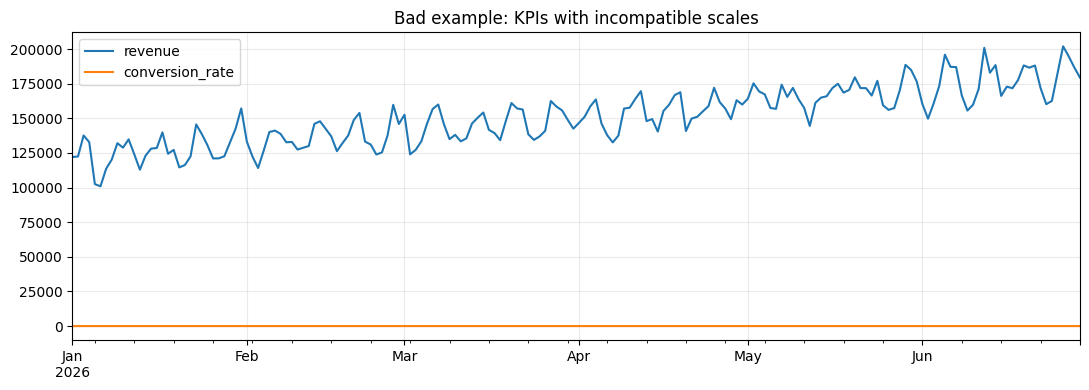

In [27]:
ax = ts[["revenue", "conversion_rate"]].plot(figsize=(11, 4))

ax.set_title("Bad example: KPIs with incompatible scales")
ax.set_xlabel("")
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

### Option A: normalize the KPIs

A simple teaching technique is to convert each KPI to an index where the first valid value equals 100.

This lets us compare *relative movement* rather than absolute units.

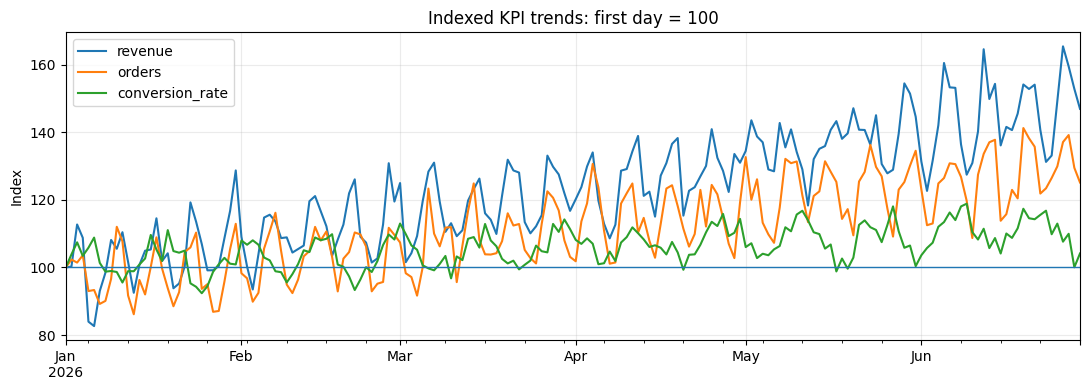

In [28]:
kpis = ts[["revenue", "orders", "conversion_rate"]].copy()

indexed = kpis / kpis.iloc[0] * 100

ax = indexed.plot(figsize=(11, 4))

ax.axhline(100, linewidth=1)
ax.set_title("Indexed KPI trends: first day = 100")
ax.set_xlabel("")
ax.set_ylabel("Index")
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

### Option B: small multiples

Small multiples are often clearer than a dual-axis chart.

Each KPI keeps its own scale while the x-axis remains aligned.

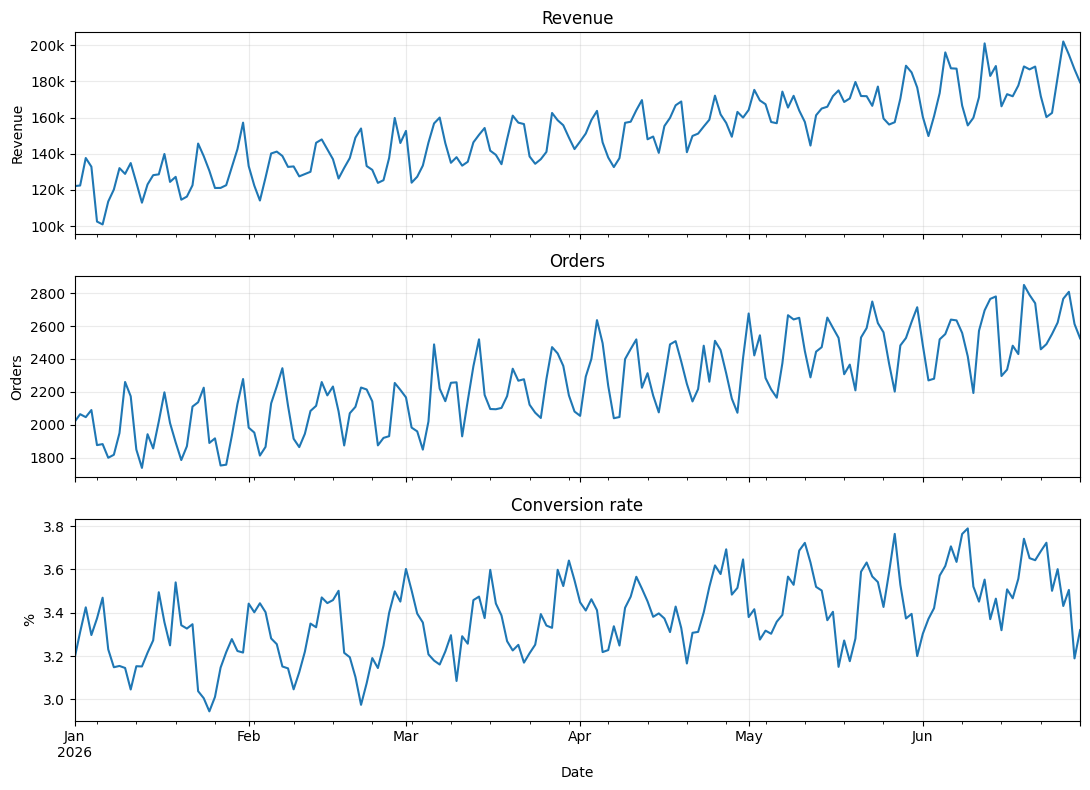

In [29]:
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)

ts["revenue"].plot(ax=axes[0])
axes[0].set_title("Revenue")
axes[0].set_ylabel("Revenue")
axes[0].yaxis.set_major_formatter(FuncFormatter(thousands_formatter))
axes[0].grid(True, alpha=0.25)

ts["orders"].plot(ax=axes[1])
axes[1].set_title("Orders")
axes[1].set_ylabel("Orders")
axes[1].grid(True, alpha=0.25)

ts["conversion_rate"].plot(ax=axes[2])
axes[2].set_title("Conversion rate")
axes[2].set_ylabel("%")
axes[2].set_xlabel("Date")
axes[2].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

### Teaching discussion

Ask:

- When do we care about **absolute level**?
- When do we care about **relative movement**?
- When do small multiples beat a single multi-line chart?
- Why can dual y-axes be misleading?

A useful rule of thumb:

> If the KPIs have different units and the comparison is not naturally meaningful, prefer small multiples.

### Manual practice — compare multiple student-entered KPIs

Here the student enters three KPIs with different units.

First we demonstrate the indexed comparison; then we use small multiples.

In [ ]:
student_multi_data = [
    {"date": "2026-09-01", "revenue": 100000, "orders": 1600, "conversion_rate": 3.00},
    {"date": "2026-09-02", "revenue": 104000, "orders": 1640, "conversion_rate": 3.10},
    {"date": "2026-09-03", "revenue": 102000, "orders": 1625, "conversion_rate": 3.00},
    {"date": "2026-09-04", "revenue": 108000, "orders": 1690, "conversion_rate": 3.20},
    {"date": "2026-09-05", "revenue": 111000, "orders": 1730, "conversion_rate": 3.30},
    {"date": "2026-09-06", "revenue": 109000, "orders": 1710, "conversion_rate": 3.25},
    {"date": "2026-09-07", "revenue": 115000, "orders": 1780, "conversion_rate": 3.40},
]

student_multi_df = pd.DataFrame(student_multi_data)
student_multi_df["date"] = pd.to_datetime(student_multi_df["date"])
student_multi_ts = student_multi_df.set_index("date").sort_index()

student_multi_ts

#### Indexed comparison: first date = 100

In [ ]:
student_multi_indexed = (
    student_multi_ts / student_multi_ts.iloc[0] * 100
)

ax = student_multi_indexed.plot(figsize=(11, 4), marker="o")

ax.axhline(100, linewidth=1)
ax.set_title("My KPIs indexed to the first date = 100")
ax.set_xlabel("")
ax.set_ylabel("Index")
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

#### Small multiples: preserve each KPI's own scale

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)

student_multi_ts["revenue"].plot(ax=axes[0], marker="o")
axes[0].set_title("Revenue")
axes[0].set_ylabel("Revenue")
axes[0].yaxis.set_major_formatter(FuncFormatter(thousands_formatter))
axes[0].grid(True, alpha=0.25)

student_multi_ts["orders"].plot(ax=axes[1], marker="o")
axes[1].set_title("Orders")
axes[1].set_ylabel("Orders")
axes[1].grid(True, alpha=0.25)

student_multi_ts["conversion_rate"].plot(ax=axes[2], marker="o")
axes[2].set_title("Conversion rate")
axes[2].set_ylabel("%")
axes[2].set_xlabel("Date")
axes[2].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

## 9. Highlight unusual periods — 5 minutes

You do not need complex anomaly-detection libraries for a first visual check.

A simple approach:

1. calculate a rolling mean,
2. calculate a rolling standard deviation,
3. flag values outside a chosen band.

This is a teaching example, not a production anomaly-detection system.

In [30]:
rolling_mean = ts["revenue"].rolling(30).mean()
rolling_std = ts["revenue"].rolling(30).std()

upper_band = rolling_mean + 2 * rolling_std
lower_band = rolling_mean - 2 * rolling_std

unusual = (ts["revenue"] > upper_band) | (ts["revenue"] < lower_band)

print("Flagged days:", unusual.sum())

Flagged days: 5


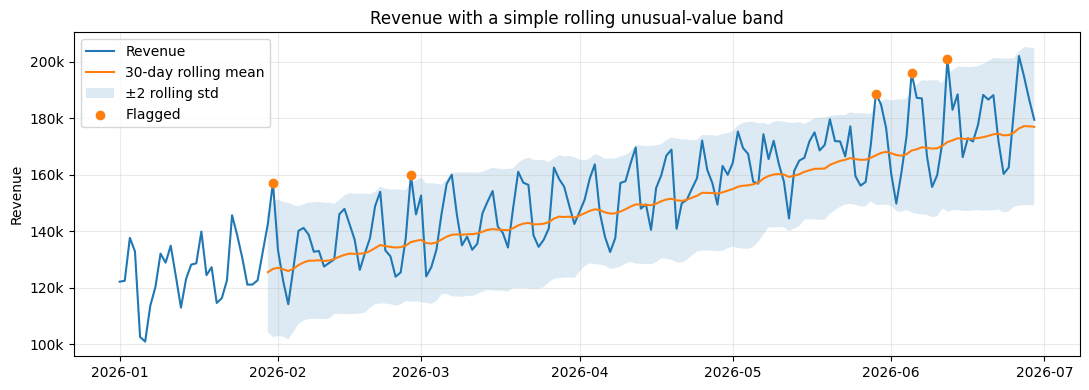

In [31]:
fig, ax = plt.subplots(figsize=(11, 4))

ax.plot(ts.index, ts["revenue"], label="Revenue")
ax.plot(ts.index, rolling_mean, label="30-day rolling mean")
ax.fill_between(ts.index, lower_band, upper_band, alpha=0.15, label="±2 rolling std")

ax.scatter(
    ts.index[unusual],
    ts.loc[unusual, "revenue"],
    label="Flagged",
    zorder=3
)

ax.set_title("Revenue with a simple rolling unusual-value band")
ax.set_xlabel("")
ax.set_ylabel("Revenue")
ax.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))
ax.grid(True, alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

### Manual practice — type an unusual value deliberately

Students can type one obvious spike and see how a simple rolling baseline reacts.

To avoid letting the current value influence its own threshold, the example builds the baseline from the **previous five observations**.

In [ ]:
student_anomaly_data = [
    {"date": "2026-10-01", "kpi": 100},
    {"date": "2026-10-02", "kpi": 103},
    {"date": "2026-10-03", "kpi": 99},
    {"date": "2026-10-04", "kpi": 102},
    {"date": "2026-10-05", "kpi": 101},
    {"date": "2026-10-06", "kpi": 104},
    {"date": "2026-10-07", "kpi": 100},
    {"date": "2026-10-08", "kpi": 103},
    {"date": "2026-10-09", "kpi": 101},
    {"date": "2026-10-10", "kpi": 135},  # deliberately unusual
    {"date": "2026-10-11", "kpi": 102},
    {"date": "2026-10-12", "kpi": 100},
]

student_anomaly_df = pd.DataFrame(student_anomaly_data)
student_anomaly_df["date"] = pd.to_datetime(student_anomaly_df["date"])
student_anomaly_ts = student_anomaly_df.set_index("date").sort_index()

prior_values = student_anomaly_ts["kpi"].shift(1)

student_roll_mean = prior_values.rolling(5).mean()
student_roll_std = prior_values.rolling(5).std()

student_upper = student_roll_mean + 2 * student_roll_std
student_lower = student_roll_mean - 2 * student_roll_std

student_flag = (
    (student_anomaly_ts["kpi"] > student_upper)
    | (student_anomaly_ts["kpi"] < student_lower)
)

pd.DataFrame({
    "kpi": student_anomaly_ts["kpi"],
    "prior_5_mean": student_roll_mean,
    "lower": student_lower,
    "upper": student_upper,
    "flagged": student_flag,
})

In [ ]:
fig, ax = plt.subplots(figsize=(11, 4))

ax.plot(
    student_anomaly_ts.index,
    student_anomaly_ts["kpi"],
    marker="o",
    label="KPI"
)

ax.plot(
    student_anomaly_ts.index,
    student_roll_mean,
    label="Prior 5-period mean"
)

ax.fill_between(
    student_anomaly_ts.index,
    student_lower,
    student_upper,
    alpha=0.15,
    label="±2 prior rolling std"
)

ax.scatter(
    student_anomaly_ts.index[student_flag],
    student_anomaly_ts.loc[student_flag, "kpi"],
    zorder=3,
    label="Flagged"
)

ax.set_title("Unusual values in my manually entered KPI")
ax.set_xlabel("")
ax.set_ylabel("KPI")
ax.grid(True, alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

**Student experiment:** change the value `135` to `110`, `120`, `150`, and `200`.
Observe when the simple rule does or does not flag the point.

## 10. Final recap exercise — 5 minutes

Build a compact weekly KPI view from the daily dataset.

### Task

1. Aggregate to weekly data.
2. Plot weekly revenue.
3. Add a 4-week rolling average.
4. Give the chart a clear title and axis labels.

Try it before viewing the solution.

In [32]:
# Final exercise: your code here

### Final exercise solution

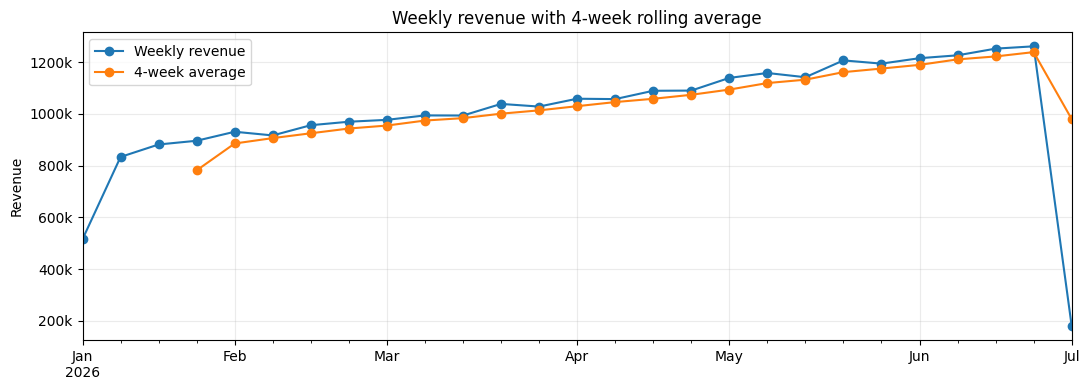

In [33]:
weekly_revenue = ts["revenue"].resample("W").sum()
weekly_revenue_4w_avg = weekly_revenue.rolling(4).mean()

weekly_plot = pd.DataFrame({
    "Weekly revenue": weekly_revenue,
    "4-week average": weekly_revenue_4w_avg,
})

ax = weekly_plot.plot(figsize=(11, 4), marker="o")

ax.set_title("Weekly revenue with 4-week rolling average")
ax.set_xlabel("")
ax.set_ylabel("Revenue")
ax.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

### Manual capstone — do the complete workflow with your own data

This final template combines the main ideas in one place.

Students should replace the example rows with a KPI from their own context.

In [ ]:
# STEP 1 — ENTER YOUR OWN DATA.
# You can add more rows; keep the same column names.

capstone_data = [
    {"date": "2026-07-05", "actual": 510000, "target": 520000},
    {"date": "2026-07-12", "actual": 535000, "target": 525000},
    {"date": "2026-07-19", "actual": 528000, "target": 530000},
    {"date": "2026-07-26", "actual": 552000, "target": 535000},
    {"date": "2026-08-02", "actual": 568000, "target": 540000},
    {"date": "2026-08-09", "actual": 561000, "target": 545000},
    {"date": "2026-08-16", "actual": 584000, "target": 550000},
    {"date": "2026-08-23", "actual": 596000, "target": 555000},
]

capstone_df = pd.DataFrame(capstone_data)
capstone_df["date"] = pd.to_datetime(capstone_df["date"])
capstone_ts = capstone_df.set_index("date").sort_index()

capstone_ts

In [ ]:
# STEP 2 — CALCULATE SUPPORTING METRICS.

capstone_ts["variance"] = capstone_ts["actual"] - capstone_ts["target"]
capstone_ts["4_period_average"] = capstone_ts["actual"].rolling(4).mean()
capstone_ts["change_pct"] = capstone_ts["actual"].pct_change() * 100

capstone_ts.round(2)

In [ ]:
# STEP 3 — BASIC ACTUAL VS TARGET CHART.

ax = capstone_ts[["actual", "target"]].plot(figsize=(11, 4), marker="o")

ax.set_title("My KPI: actual vs target")
ax.set_xlabel("")
ax.set_ylabel("Value")
ax.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

In [ ]:
# STEP 4 — ACTUAL WITH ROLLING AVERAGE.

ax = capstone_ts[["actual", "4_period_average"]].plot(
    figsize=(11, 4),
    marker="o"
)

ax.set_title("My KPI with rolling average")
ax.set_xlabel("")
ax.set_ylabel("Value")
ax.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

In [ ]:
# STEP 5 — PERCENTAGE CHANGE.

ax = capstone_ts["change_pct"].plot(figsize=(11, 3), marker="o")

ax.axhline(0, linewidth=1)
ax.set_title("Change in my KPI")
ax.set_xlabel("")
ax.set_ylabel("Change (%)")
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

### Capstone questions for students

1. What is the overall direction of your KPI?
2. Which periods are above target?
3. Does the rolling average tell a different story than the raw values?
4. Which period has the largest positive or negative percentage change?
5. Is the time granularity appropriate for the business question?
6. Would `sum()` or `mean()` be appropriate if you aggregated the data?

# Summary: the simplest useful toolkit

For most KPI time series, start with these patterns:

### 1. Basic trend
```python
ts["kpi"].plot()
```

### 2. Actual vs target
```python
ts[["actual", "target"]].plot()
```

### 3. Rolling average
```python
ts["kpi"].rolling(7).mean()
```

### 4. Percentage change
```python
ts["kpi"].pct_change(7) * 100
```

### 5. Weekly or monthly aggregation
```python
ts["kpi"].resample("W").sum()
ts["rate_kpi"].resample("W").mean()
```

### 6. Compare different KPI scales
Use either:

- indexed values,
- or small multiples.

### 7. Highlight unusual periods
Start with rolling bands, then move to more advanced anomaly detection only when needed.

---

## Practical checklist

Before showing a KPI chart, ask:

1. What business question should this chart answer?
2. Is the time granularity appropriate?
3. Is the aggregation mathematically correct?
4. Are units clearly visible?
5. Is a target or baseline needed?
6. Would a rolling average help?
7. Are multiple KPIs actually comparable?
8. Is the chart simple enough to explain in a few seconds?

---

## Optional homework

Use your own dataset and create four charts:

1. raw time-series KPI,
2. KPI with target,
3. KPI with rolling average,
4. weekly or monthly KPI.

Then write one sentence under each chart explaining the business insight.

# Manual-entry reference card

The following patterns are enough for most short classroom exercises.

### Enter rows manually

```python
data = [
    {"date": "2026-01-01", "kpi": 100},
    {"date": "2026-01-02", "kpi": 105},
]

df = pd.DataFrame(data)
df["date"] = pd.to_datetime(df["date"])
ts = df.set_index("date").sort_index()
```

### Plot

```python
ts["kpi"].plot()
```

### Add a target

```python
ts[["actual", "target"]].plot()
```

### Rolling average

```python
ts["rolling_avg"] = ts["kpi"].rolling(7).mean()
```

### Percentage change

```python
ts["change_pct"] = ts["kpi"].pct_change() * 100
```

### Aggregate

```python
weekly_total = ts["flow_kpi"].resample("W").sum()
weekly_rate = ts["rate_kpi"].resample("W").mean()
```

The important point is that students do **not** need a CSV file or database to learn these techniques.
A small list of manually typed rows is enough to practice the entire workflow.